In [ ]:
import os

# Ganti dengan token Kaggle Anda sendiri
os.environ['KAGGLE_CONFIG_DIR'] = '/content/'
# os.environ['KAGGLE_API_TOKEN'] = 'ISI_TOKEN_DI_SINI'

In [ ]:
# Download dataset
!kaggle datasets download -d prasunroy/natural-images

# Ekstrak filenya
import zipfile
with zipfile.ZipFile("natural-images.zip", "r") as zip_ref:
    zip_ref.extractall("/tmp")

Dataset URL: https://www.kaggle.com/datasets/prasunroy/natural-images
License(s): CC-BY-NC-SA-4.0
natural-images.zip: Skipping, found more recently modified local copy (use --force to force download)


# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Imammul Arif
- **Email:** imammularif@gmail.com
- **ID Dicoding:** imammul_arif

## Import Semua Packages/Library yang Digunakan

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile

## Data Preparation

### Data Loading

In [ ]:
import zipfile
import os

# 1. Sesuaikan nama file zip yang ada di sidebar kamu
local_zip = 'natural-images.zip'

# 2. Proses ekstrak (Python yang kerjakan, cuma butuh waktu hitungan detik)
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

# 3. Tentukan alamat folder hasil ekstrak (biasanya nama folder di dalam zip)
# Cek dulu nama foldernya di /tmp setelah diekstrak
base_dir = '/tmp/natural_images'

### Data Preprocessing

#### Split Dataset

In [ ]:
import zipfile
import os

# GANTI ini dengan nama file zip yang ada di sidebar kiri
local_zip = 'natural-images.zip'

# Proses Ekstrak
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/data_input') # Kita ekstrak ke folder baru bernama data_input
zip_ref.close()

print("Berhasil Ekstrak! Sekarang kita cek isinya.")
!ls /content/data_input

Berhasil Ekstrak! Sekarang kita cek isinya.
data  natural_images


In [ ]:
import splitfolders
import os

# Sesuaikan dengan nama folder hasil ekstrak tadi
input_dir = '/content/data_input/natural_images'

# Proses Split: 80% Train, 10% Val, 10% Test
splitfolders.ratio(input_dir, output="dataset_split", seed=42, ratio=(.8, .1, .1))

print("Pembagian data selesai!")
# Cek apakah folder sudah terbagi benar
!ls dataset_split

Copying files: 6899 files [00:01, 3500.33 files/s]


Pembagian data selesai!
test  train  val


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Konfigurasi Augmentasi (Hanya untuk Training)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    fill_mode='nearest'
)

# Konfigurasi Rescale (Untuk Val & Test tidak perlu augmentasi)
test_datagen = ImageDataGenerator(rescale=1./255)

# 1. Training Generator
train_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# 2. Validation Generator
validation_generator = test_datagen.flow_from_directory(
    'dataset_split/val',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# 3. Test Generator (Wajib ada sesuai permintaan reviewer)
test_generator = test_datagen.flow_from_directory(
    'dataset_split/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 5516 images belonging to 8 classes.
Found 686 images belonging to 8 classes.
Found 697 images belonging to 8 classes.


## Modelling

In [ ]:
# --- TAHAP MEMASAK (TRAINING) ---

# 1. Kita bangun arsitektur modelnya dulu
model = tf.keras.models.Sequential([
    # Layer untuk melihat pola gambar
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Layer untuk mengubah data jadi 1D
    tf.keras.layers.Flatten(),

    # Layer inti (otak)
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Output (sesuai jumlah kategori gambar)
    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

# 2. Kita tentukan bumbu belajarnya (Compile)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 3. KITA MULAI MASAK (Ini yang bikin variabel 'history' ada)
print("Sedang melatih model... Mohon tunggu sebentar.")
history = model.fit(
    train_generator,
    epochs=15, # Kita coba 15 kali putaran belajar
    validation_data=validation_generator,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Sedang melatih model... Mohon tunggu sebentar.
Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 47s 242ms/step - accuracy: 0.7079 - loss: 1.0577 - val_accuracy: 0.8659 - val_loss: 0.3428
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 205ms/step - accuracy: 0.8611 - loss: 0.3958 - val_accuracy: 0.8776 - val_loss: 0.3150
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 207ms/step - accuracy: 0.8780 - loss: 0.3280 - val_accuracy: 0.9096 - val_loss: 0.2356
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 209ms/step - accuracy: 0.8965 - loss: 0.2765 - val_accuracy: 0.9213 - val_loss: 0.1876
Epoch 5/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 37s 212ms/step - accuracy: 0.9061 - loss: 0.2521 - val_accuracy: 0.9052 - val_loss: 0.2417
Epoch 6/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 210ms/step - accuracy: 0.9182 - loss: 0.2179 - val_accuracy: 0.9227 - val_loss: 0.2003
Epoch 7/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 210ms/step - accuracy: 0.9208 - loss: 0.2103 - val_accuracy: 0.9096 - val_loss: 0.2352
Epoch 8/15
173/173 ━━━━━━━━━━━━━━━━━

## Evaluasi dan Visualisasi

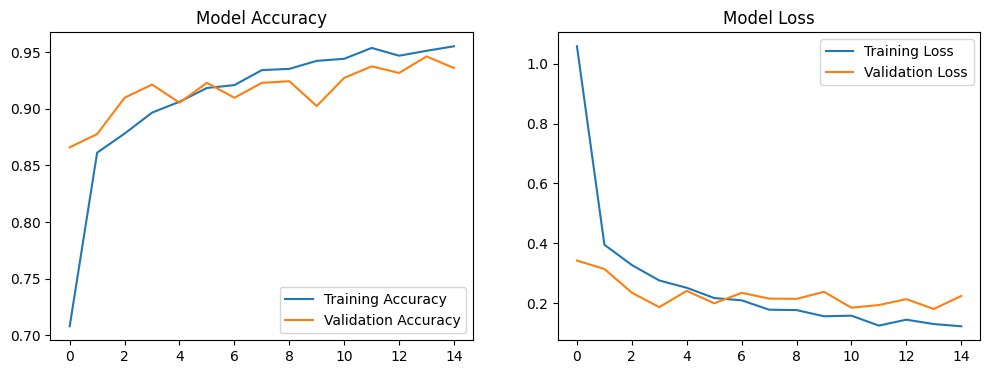

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Grafik Loss (Wajib ada!)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

## Konversi Model

In [ ]:
# --- STEP 1: Buat Folder Sesuai Struktur Template ---
!mkdir -p submission/tfjs_model
!mkdir -p submission/tflite
!mkdir -p submission/saved_model

# --- STEP 2: Konversi ke SavedModel (Cara Baru) ---
# Di Keras 3, gunakan model.export() untuk format SavedModel
model.export('submission/saved_model')

# --- STEP 3: Konversi ke TFLite ---
# Gunakan converter dari direktori yang baru saja di-export
converter = tf.lite.TFLiteConverter.from_saved_model('submission/saved_model')
tflite_model = converter.convert()

with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

# Membuat file label.txt otomatis
labels = '\n'.join(sorted(train_generator.class_indices.keys()))
with open('submission/tflite/label.txt', 'w') as f:
    f.write(labels)

# --- STEP 4: Konversi ke TFJS ---
!pip install tensorflowjs
import tensorflowjs as tfjs
# TFJS juga bisa mengambil dari folder SavedModel tadi
tfjs.converters.convert_tf_saved_model('submission/saved_model', 'submission/tfjs_model')

# --- STEP 5: Buat Requirements.txt ---
!pip freeze > submission/requirements.txt

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  140054765280848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140054765281616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140054765283152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140054765281232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140054765282576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140054765284880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140054765284688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140054765282768: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Inference (Optional)

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

for fn in uploaded.keys():
  path = fn
  img = load_img(path, target_size=(150, 150))
  img_tensor = img_to_array(img) / 255.0
  img_tensor = np.expand_dims(img_tensor, axis=0)

  classes = model.predict(img_tensor)
  result = np.argmax(classes)

  # Ambil nama labelnya
  labels = list(train_generator.class_indices.keys())
  print(f'File: {fn}, Prediksi: {labels[result]}')

Saving dog_0691.jpg to dog_0691.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step
File: dog_0691.jpg, Prediksi: dog


In [ ]:
# Membuat file requirements.txt
!pip freeze > requirements.txt

In [ ]:
import shutil

# Mengompres folder 'submission' menjadi 'hasil_submission.zip'
shutil.make_archive('hasil_submission', 'zip', 'submission')

print("File ZIP berhasil dibuat!")

File ZIP berhasil dibuat!


In [ ]:
from google.colab import files

# Download file zip yang tadi dibuat
files.download('hasil_submission.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>